# Explainable Boosting Machine DEMO

- california housing dataset (sklearn): https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

- EBM: https://interpret.ml/docs/hyperparameters.html

# 0. Dataset info

Shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float6

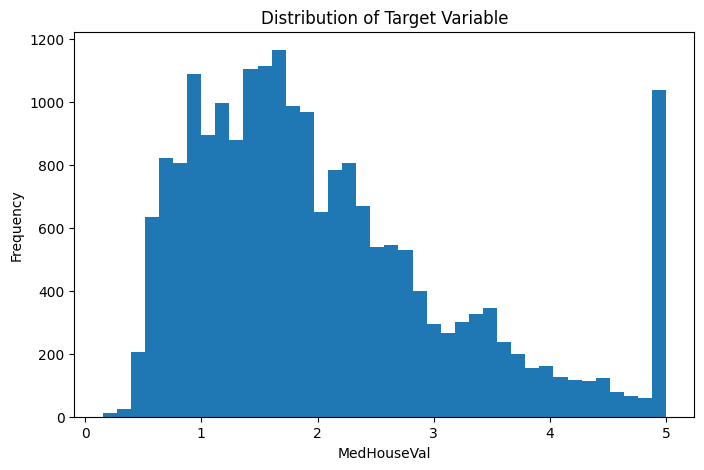

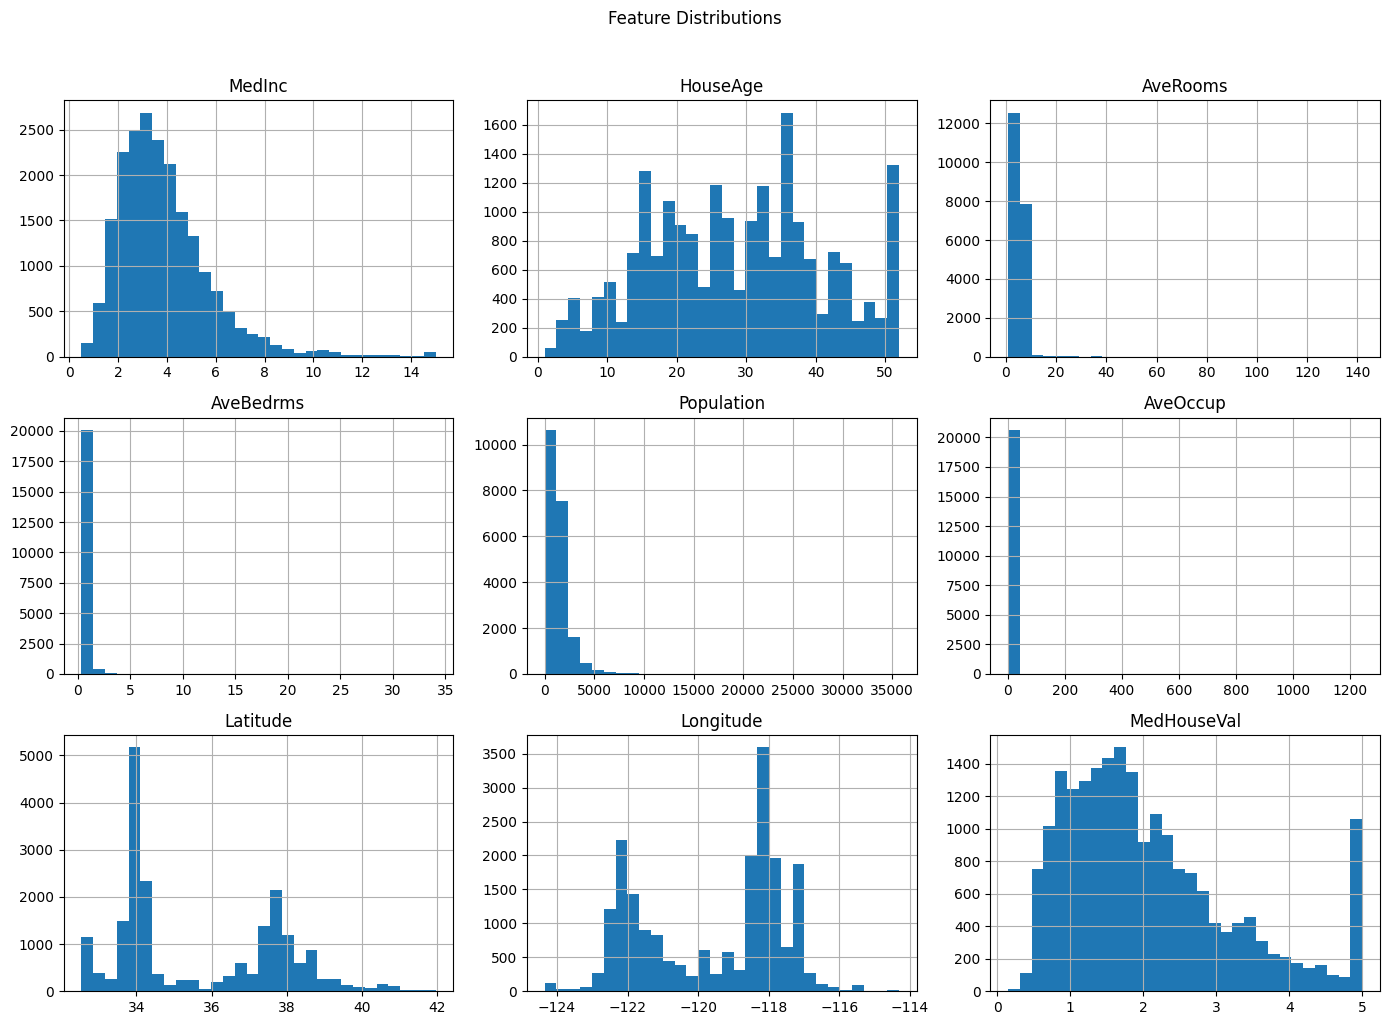


Correlation with target:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


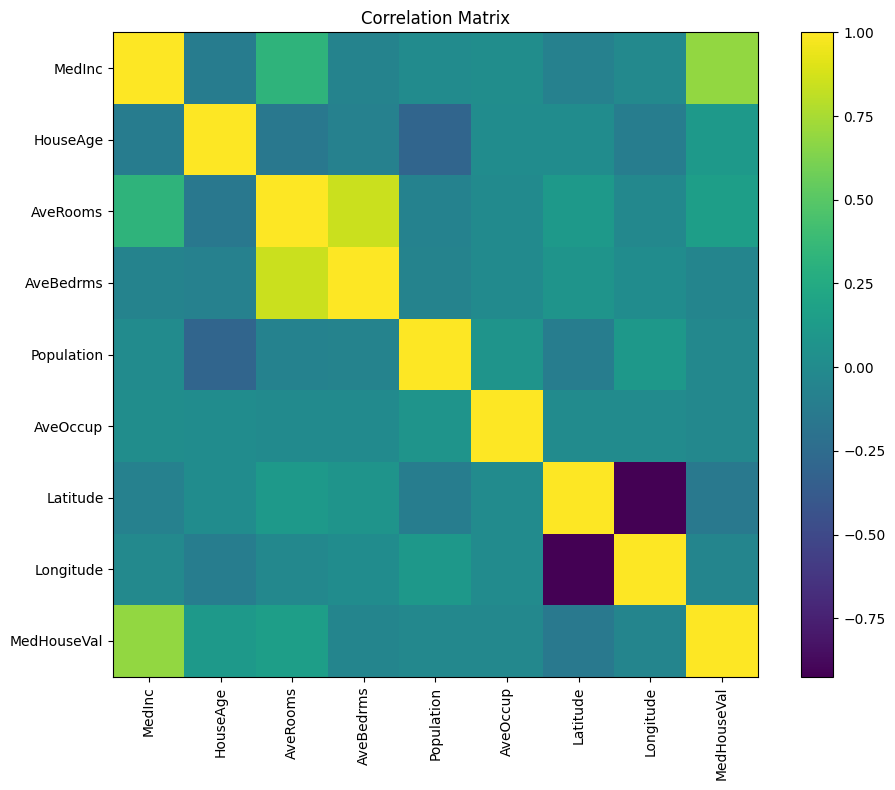

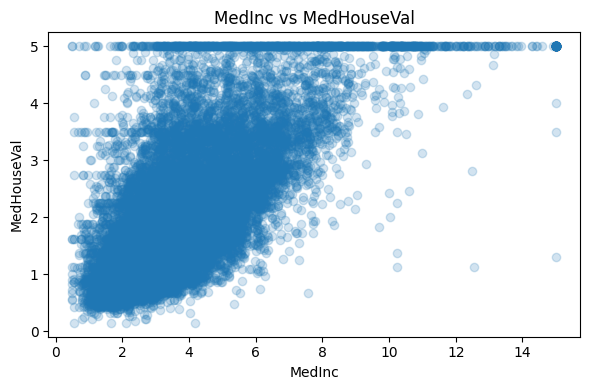

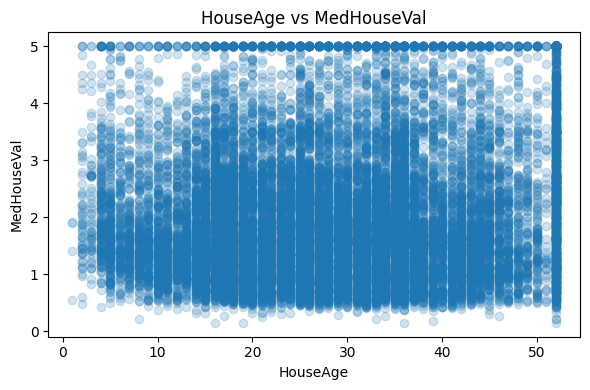

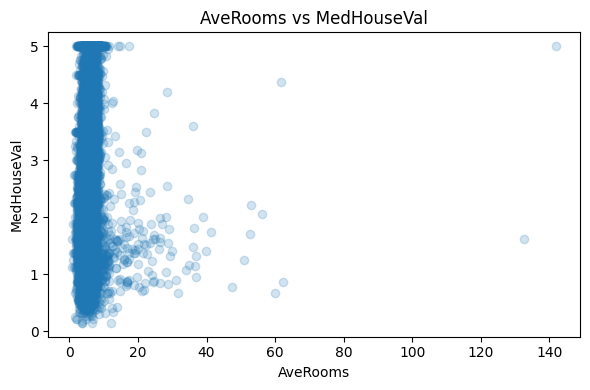

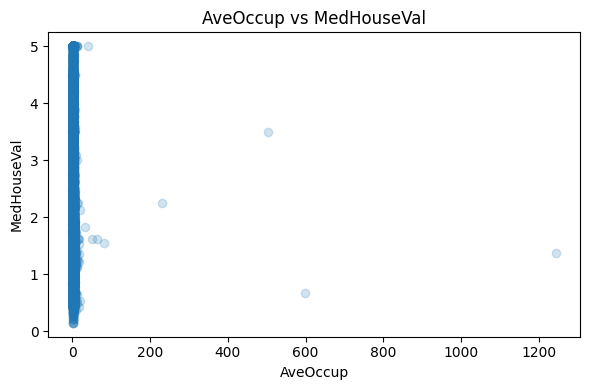


Unique values per column:
MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64

Rows with max target:
     MedHouseVal  MedInc  HouseAge  AveRooms  Latitude  Longitude
89       5.00001  1.2434      52.0  2.929412     37.80    -122.27
459      5.00001  1.1696      52.0  2.436000     37.87    -122.25
493      5.00001  7.8521      52.0  7.794393     37.86    -122.24
494      5.00001  9.3959      52.0  7.512097     37.85    -122.24
509      5.00001  7.8772      52.0  8.282548     37.83    -122.23

Rows with min target:
       MedHouseVal  MedInc  HouseAge   AveRooms  Latitude  Longitude
2521       0.14999  1.6607      16.0   6.710526     39.71    -122.74
2799       0.14999  2.1000      19.0   3.774390     36.40    -117.02
9188       0.14999  4.1932      52.0   3.568889     34.24    -117.86
19802      0.14999  0.5360      36.0  12.250000     4

In [11]:
#!pip install interpret
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from interpret.glassbox import ExplainableBoostingRegressor
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())


target_col = "MedHouseVal"

print(f"\nTarget variable: {target_col}")
print(df[target_col].describe())

plt.figure(figsize=(8, 5))
plt.hist(df[target_col], bins=40)
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()


df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


corr = df.corr(numeric_only=True)

print("\nCorrelation with target:")
print(corr[target_col].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


key_features = ["MedInc", "HouseAge", "AveRooms", "AveOccup"]

for col in key_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df[target_col], alpha=0.2)
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.title(f"{col} vs {target_col}")
    plt.tight_layout()
    plt.show()


print("\nUnique values per column:")
print(df.nunique())

print("\nRows with max target:")
print(df.nlargest(5, target_col)[[target_col, "MedInc", "HouseAge", "AveRooms", "Latitude", "Longitude"]])

print("\nRows with min target:")
print(df.nsmallest(5, target_col)[[target_col, "MedInc", "HouseAge", "AveRooms", "Latitude", "Longitude"]])




# 1. Usporedba performansi modela (RMSE)

In [20]:
X = housing.data
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# modeli za usporedbu
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)


#EBM
ebm = ExplainableBoostingRegressor(
    random_state=42,
    interactions=3,
    outer_bags=8,
    inner_bags=0,
    max_rounds=500,
    learning_rate=0.04,
    max_bins=256,
    max_leaves=2,
    smoothing_rounds=500,
    n_jobs=-1
)

models = {
    "LR": lr,
    "DT": dt,
    "XGB": xgb,
    "EBM": ebm
}


for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name}: RMSE = {rmse:.4f}")



LR: RMSE = 0.7456
DT: RMSE = 0.7242
XGB: RMSE = 0.5110
EBM: RMSE = 0.5403


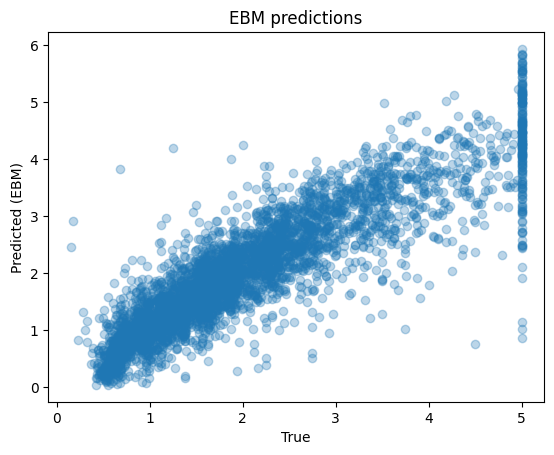

In [21]:
plt.scatter(y_test, ebm.predict(X_test), alpha=0.3)
plt.xlabel("True")
plt.ylabel("Predicted (EBM)")
plt.title("EBM predictions")
plt.show()

# 2. Interpretacija

In [26]:
from interpret import show

ebm_global = ebm.explain_global()
show(ebm_global)

*Za lat-long interakciju, žuto područje je otprilike zona LA-a*

In [27]:
ebm_local = ebm.explain_local(X_test[:5], y_test[:5])
show(ebm_local)

*```Intercept``` je baseline (otprilike prosječna cijena)*